## Loading Data frame and cleaning

In [53]:
#can remove
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import math
import re

In [37]:
#can remove
#load in data frame
df = pd.read_csv('data/raw/combined_raw.csv')
df.head()

,university,id,webPublicationDate,sectionId,sectionName,webTitle,wordcount
0,University of Birmingham,theguardian/2010/jan/03/simonedebeauvoir-oxfor...,2010-01-03T18:36:43Z,global,Global,Elizabeth Fallaize obituary,1007
1,University of Birmingham,education/2010/jan/19/gel-curb-appetite-scient...,2010-01-19T00:05:05Z,education,Education,Food scientists develop appetite-curbing gel,839
2,University of Birmingham,science/2010/jan/25/mary-english-obituary,2010-01-25T18:38:39Z,science,Science,Mary English obituary,931
3,University of Birmingham,science/video/2010/feb/03/good-guys-draw-faste...,2010-02-03T04:50:00Z,science,Science,Video: Why the good guys draw faster in a gunf...,0
4,University of Birmingham,education/2010/feb/06/cv-clinic-jenny-adams,2010-02-06T00:05:03Z,education,Education,CV Clinic,552


In [40]:
#making datetime objects
df['webPublicationDate'] = pd.to_datetime(df['webPublicationDate'])
df['webPublicationDate'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 25142 entries, 0 to 25141
Series name: webPublicationDate
Non-Null Count  Dtype              
--------------  -----              
25142 non-null  datetime64[ns, UTC]
dtypes: datetime64[ns, UTC](1)
memory usage: 196.6 KB


In [41]:
df['webTitle'] = df['webTitle'].str.lower()

## 1. Themes Analysis

### Section breakdown

In [42]:
#sorting into table so easier to visualise data
uni_section = df.groupby(['university', 'sectionName']).size()
uni_section = uni_section.unstack(fill_value=0)
uni_section.sort_index()
uni_section.head()
uni_section

sectionName,Activate,Art and design,Australia news,Best of Birmingham,Best practice exchange,Books,Break into tech,Business,Business to business,Cardiff,...,Thinking about money,Travel,UK news,US news,Voluntary Sector Network,Wellness,Women in Leadership,Working in development,World news,Zurich School Competition
university,,,,,,,,,,,,,,,,,,,,,
Cardiff University,0,5,1,0,1,22,0,25,0,135,...,0,3,88,1,2,0,1,1,71,0
Imperial College London,0,17,4,0,0,26,1,67,0,0,...,0,1,75,19,1,0,2,3,608,1
London School of Economics,0,34,8,0,0,104,0,344,1,0,...,1,0,205,21,6,0,1,15,445,0
University College London,0,70,8,0,0,244,0,113,0,1,...,1,4,215,22,2,1,0,5,613,0
University of Birmingham,0,18,2,4,0,19,2,36,0,0,...,0,4,48,5,8,2,1,8,150,0
University of Bristol,0,9,3,0,0,21,0,20,0,0,...,0,1,72,6,3,0,0,2,190,0
University of Cambridge,2,30,10,0,0,43,0,57,2,0,...,0,1,91,19,2,1,2,1,286,0
University of Edinburgh,0,17,2,0,0,38,1,24,0,2,...,0,2,59,4,0,1,0,7,293,0
University of Manchester,0,32,3,0,0,51,0,51,0,1,...,0,8,117,6,1,0,0,5,107,0


### Creating bar chart breakdowns for individual universities

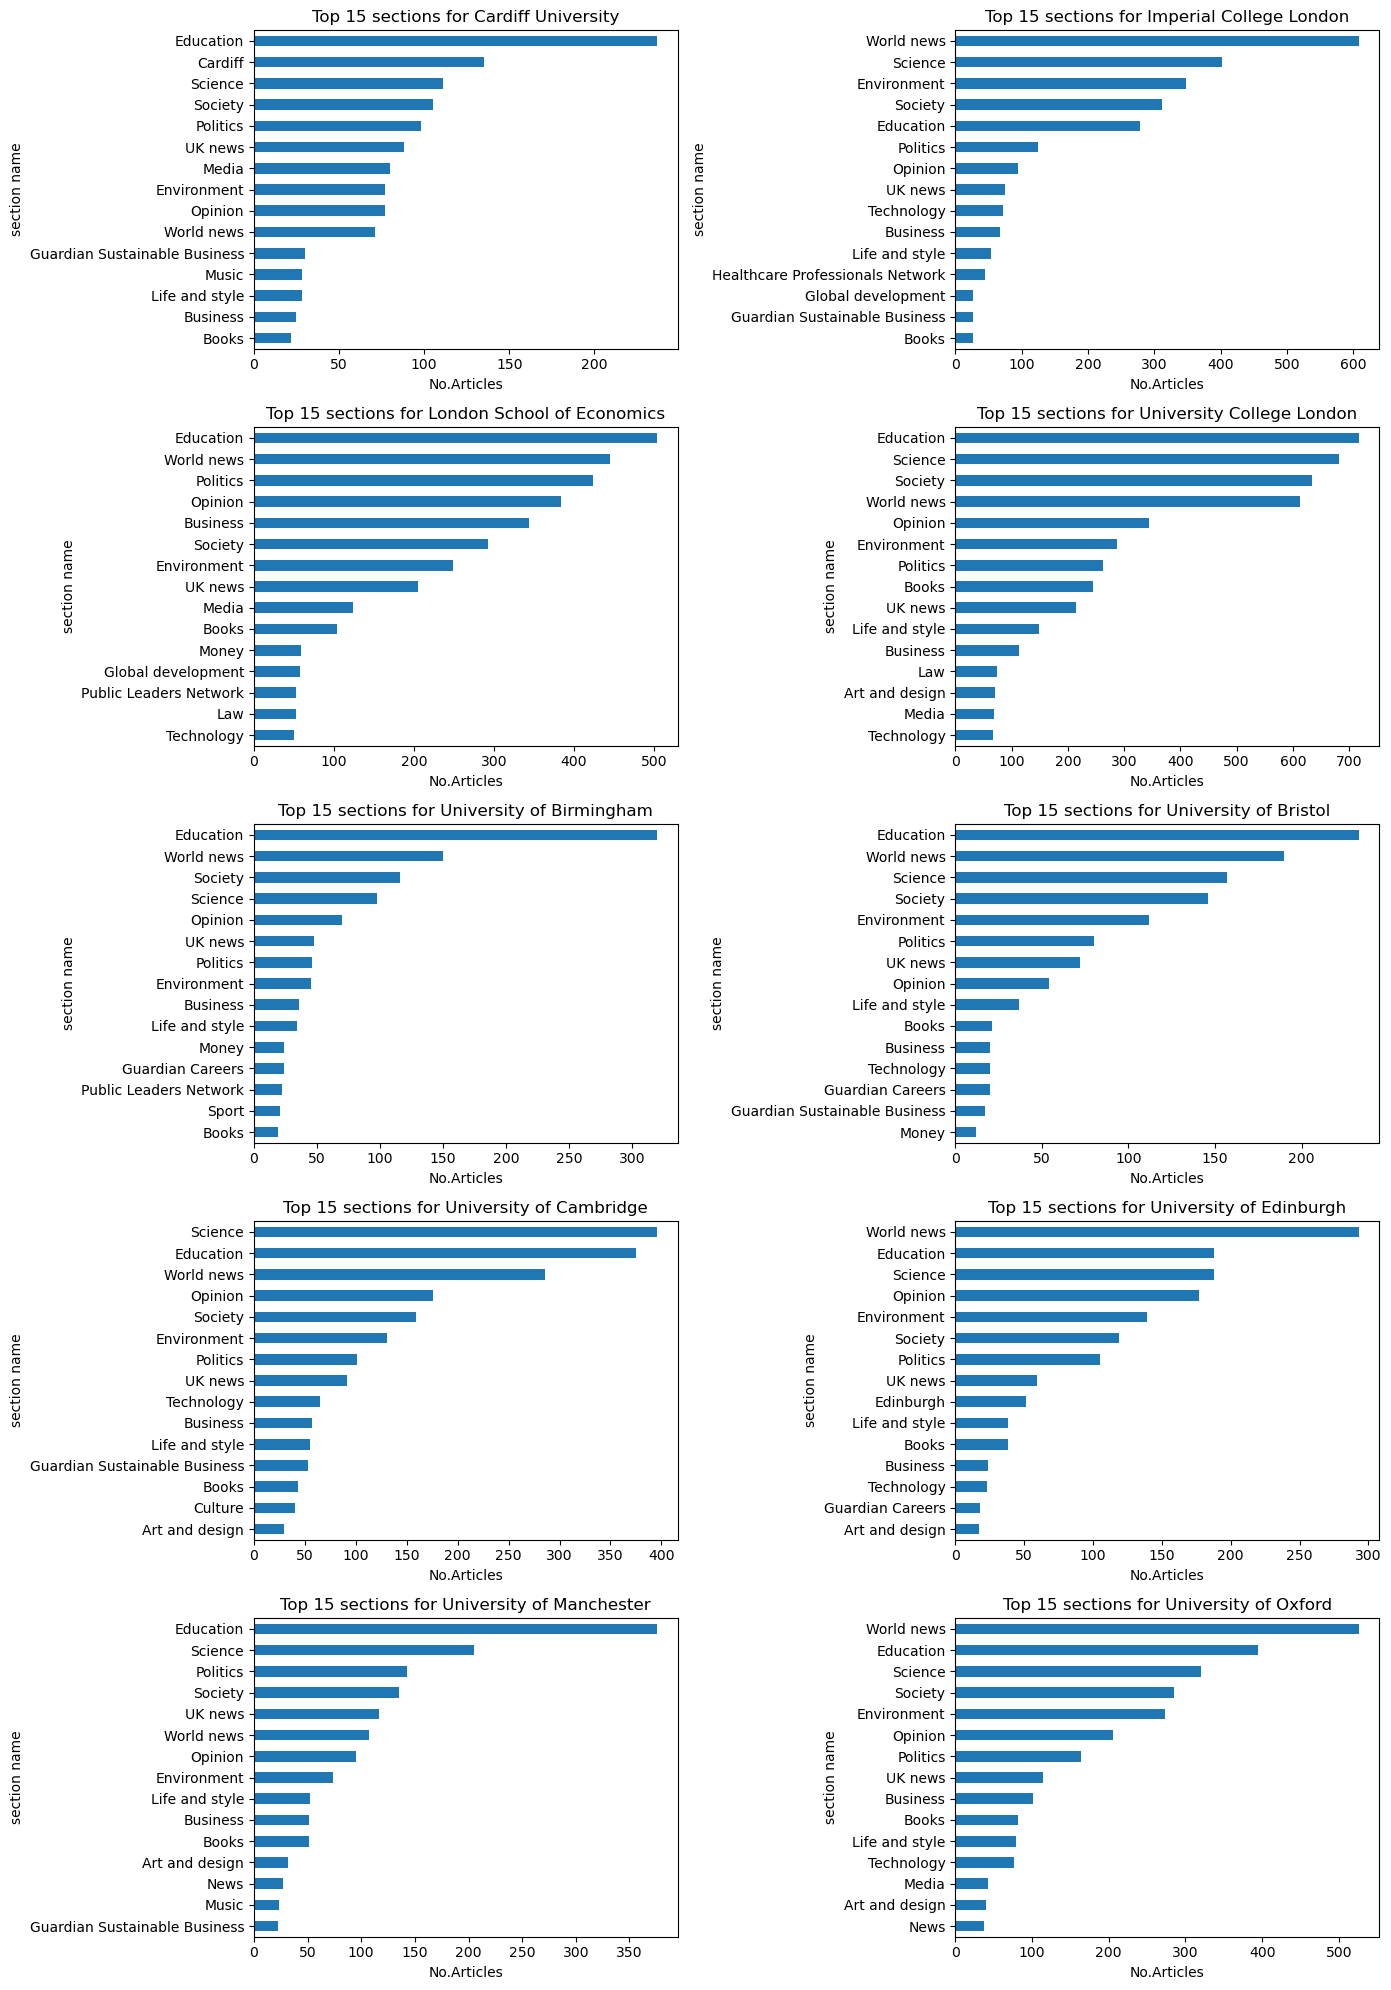

In [55]:
#putting bar charts side by side to visualise better
unis = uni_section.index

COLS = 2
rows = math.ceil(len(unis) / COLS)

fig, axes = plt.subplots(rows, COLS, figsize=(14, rows * 4))
axes = axes.flatten() 

for i, uni in enumerate(unis):
    data = uni_section.loc[uni]
    top15 = data.sort_values(ascending=False).head(15)

    top15.sort_values().plot(kind='barh', ax=axes[i])
    axes[i].set_title(f"Top 15 sections for {uni}")
    axes[i].set_xlabel("No.Articles")
    axes[i].set_ylabel("section name")

plt.tight_layout()
plt.show()

Across all ten universities, the most common sections covered are 'Education' and 'World news'. But looking at each of the individual bar charts, you can also see the individuality of each of the universities from some key differences.

Starting with LSE, after 'Education' and 'World news', the most covered sections are 'Politics', 'Opinion' and 'Business'. This aligns with what the university is known for - social science and the political relevance of its research output. Oxford and Cambridge appear frequently across a variety of sections, especially 'Science' and 'Society', separating them from specialist universities. Imperial College London is also a good example of a specialist university, being widely covered in 'Science', which shows it is known for its STEM courses. Universities such as Cardiff have a more even spread across fewer sections, which could possibly reflect a lower total article volume rather than focusing on what they are known for. 

These differences show that Guardian coverage of universities depends on each university's subject strengths and public reputation, not just on its size. 

### Section coverage and Article count per university

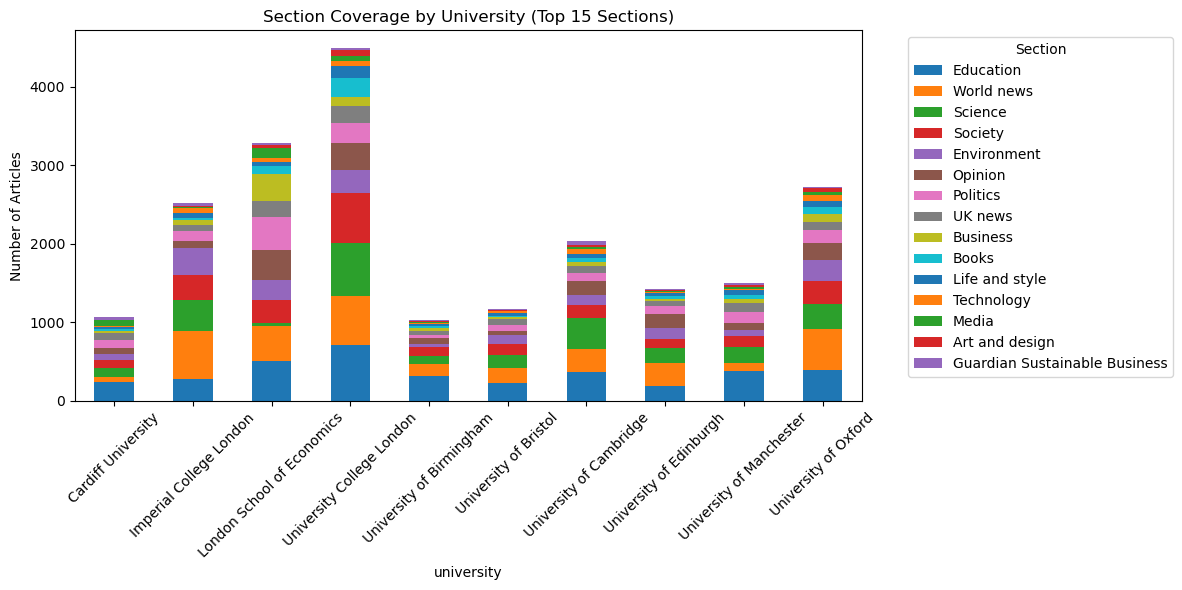

In [44]:
#need to put them all into one and colour coded so that it is easier to compare

top_sections = uni_section.sum().sort_values(ascending=False).head(15).index
filtered = uni_section[top_sections]

filtered.plot(kind='bar', stacked=True, figsize=(12,6))

plt.title("Section Coverage by University (Top 15 Sections)")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)
plt.legend(title="Section", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

We decided to only use the top 15 sections for each university or else the data gets too much and there is not much useful analysis that can be done. 

When comparing all the universities simultaneously using a stacked chart, the majority of Articles covered for all of them are Education, World News and Science. It is also easier to see the difference in the number of raw articles produced for each university as well - LSE and Imperial leading with the most articles written. Cardiff, UCL and Birmingham have the lowest amount of articles, but it is still above 1000 per university. This means the universities with a lot more articles written can visually dominate the stacked chart. This means normalising the proportions is important to get a clearer overview, which we have done next. 

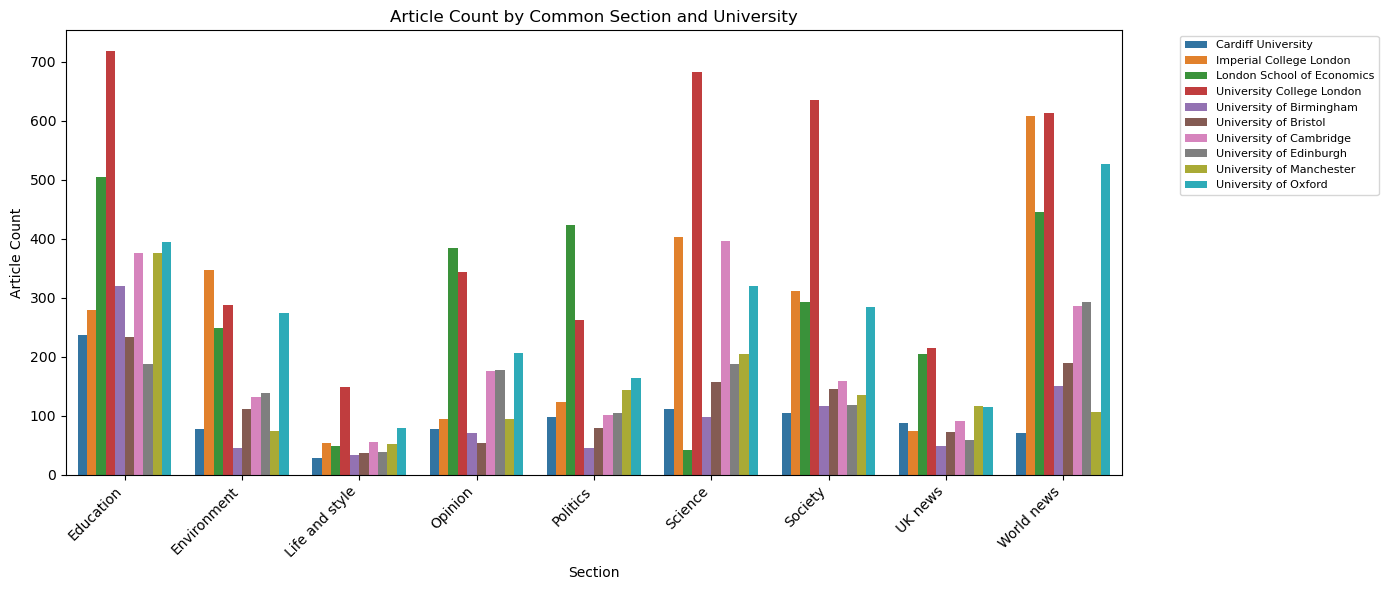

In [54]:
#categrosing further so it is only section names all the unis have in common and only the ones with more than 20 articles each
common_melted = common.reset_index().melt(id_vars='university', var_name='Section', value_name='Article Count')

plt.figure(figsize=(14, 6))
sns.barplot(data=common_melted, x='Section', y='Article Count', hue='university')
plt.title('Article Count by Common Section and University')
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## 2. Keyword Frequency Analysis

Our research questions ask about politics vs education vs events, the differences between universities and spikes around major events such as covid. So we picked a keyword set that relate to these inidividual sections and stored it in a dictionary relating the key words to individual keys. 

In [33]:
keywords = {
    "tuition_fees": ["tuition", "fees", "student debt", "budget"],
    "research": ["research", "study", "scientists", "discovery"],
    "rankings": ["ranking", "ranked", "top university", "league table"],
    "politics": ["government", "policy", "minister", "brexit", "regulation"],
    "covid": ["covid", "pandemic", "lockdown", "coronavirus"],
    "strike": ["strike", "union", "walkout", "industrial action"],
    "international": ["international", "overseas", "visa", "foreign students", "immigration"],
    "funding": ["funding", "investment", "cuts"]
}

In [47]:


keyword_patterns = {
    key: r"|".join([re.escape(word) for word in words])
    for key, words in keywords.items()
}
results = []

for uni in df['university'].unique():
    subset = df[df['university'] == uni]

    for category, pattern in keyword_patterns.items():
        count = subset['webTitle'].str.contains( #using pandas string method
            pattern,
            case=False,
            na=False
        ).sum()

        results.append({
            "university": uni,
            "category": category,
            "count": count
        })

keyword_df = pd.DataFrame(results) #storing in a dataframe

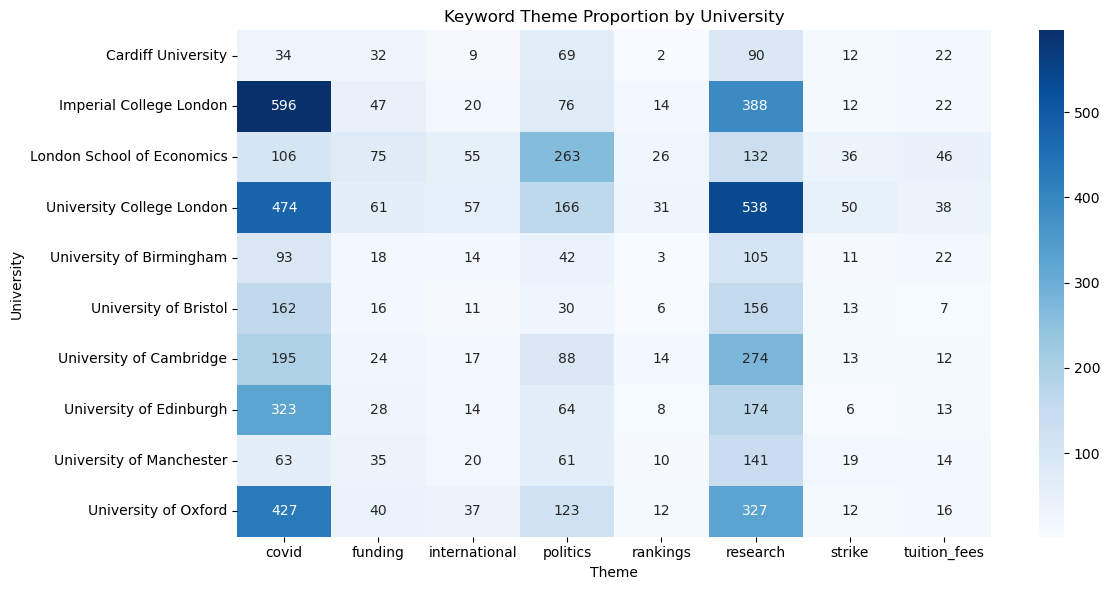

In [52]:
keyword_pivot = keyword_df.pivot(
    index='university',
    columns='category',
    values='count'
).fillna(0)

keyword_pivot
total_articles = df['university'].value_counts()

keyword_pivot_norm = keyword_pivot.div(total_articles, axis=0)

keyword_pivot_norm


plt.figure(figsize=(12,6))

keyword_pivot = keyword_df.pivot(
    index='university',
    columns='category',
    values='count'
).fillna(0)

sns.heatmap(
    keyword_pivot,
    annot=True,
    cmap="Blues",
    fmt=".0f"   # no decimals
)

plt.title("Keyword Theme Proportion by University")
plt.ylabel("University")
plt.xlabel("Theme")
plt.tight_layout()
plt.show()

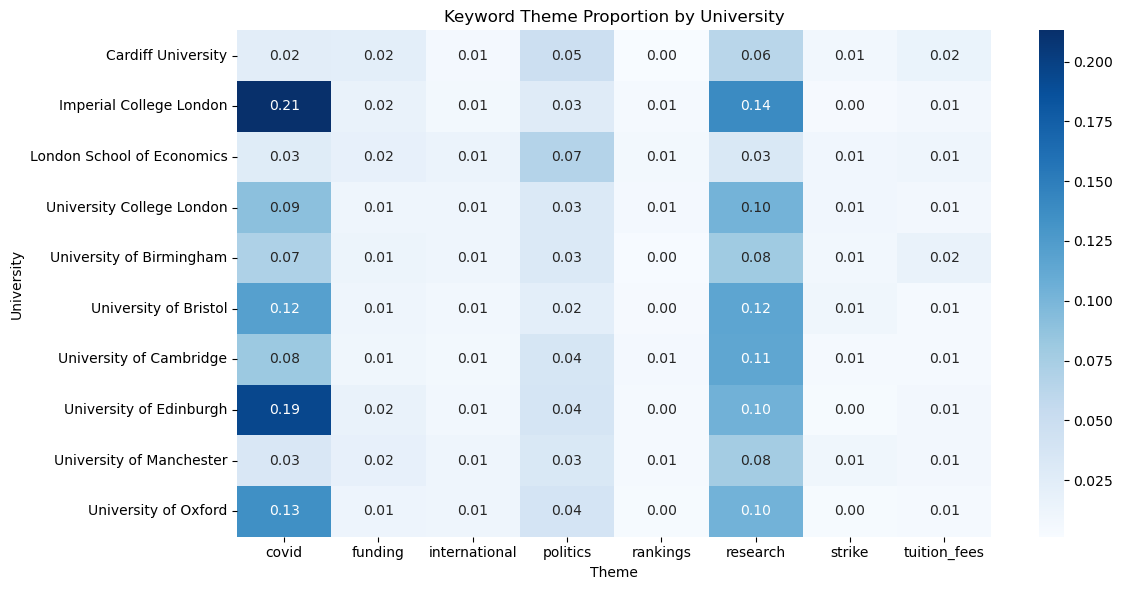

In [48]:
keyword_pivot = keyword_df.pivot(
    index='university',
    columns='category',
    values='count'
).fillna(0)

keyword_pivot
total_articles = df['university'].value_counts()

keyword_pivot_norm = keyword_pivot.div(total_articles, axis=0) #uses proportion of keyword count/total articles for that university

keyword_pivot_norm


plt.figure(figsize=(12,6))

sns.heatmap(
    keyword_pivot_norm,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Keyword Theme Proportion by University")
plt.ylabel("University")
plt.xlabel("Theme")
plt.tight_layout()
plt.show()

In [49]:
keyword_df.head()

,university,category,count
0,University of Birmingham,tuition_fees,22
1,University of Birmingham,research,105
2,University of Birmingham,rankings,3
3,University of Birmingham,politics,42
4,University of Birmingham,covid,93
